# 😴 Sleep Quality Scoring & Next-Day Performance Prediction
## From Wearable Biosignals to Actionable Health Intelligence

---

**Domain:** Digital Health · Wearable Devices · Neuro & Physiology  
**Skills demonstrated:** Signal processing, HRV analysis, feature engineering from biosignals, regression & classification, product thinking  
**Target audience:** Garmin, Oura, Withings, WHOOP, Deloitte Digital Health, McKinsey Healthcare, health-tech startups  
**Dataset:** MMASH — Multilevel Monitoring of Activity and Sleep in Healthy People (PhysioNet, open access)  
**Dataset URL:** https://physionet.org/content/mmash/1.0.0/

---

## The Product Question

> *A wearable health company wants to move beyond step counts. Their new feature: a nightly sleep score (0–100) and a "readiness" prediction for the next day, derived entirely from the sensor data already on the wrist — heart rate variability, movement, and sleep staging.*
>
> *Can we build a data pipeline that turns raw RR-interval and accelerometer data into a personalized, interpretable score — with enough transparency to satisfy both users and regulators?*

This notebook is structured as a **digital health product analytics case**:

1. **Signal Exploration** — understand what the raw data looks like
2. **Feature Engineering** — extract clinically-grounded HRV and activity features
3. **Sleep Quality Scoring** — build a composite, interpretable score
4. **Readiness Prediction** — predict next-day activity level from overnight physiology
5. **Product Framing** — translate findings into user-facing insights

---

## 0. Setup

### About the Dataset

MMASH contains 24-hour continuous recordings from **22 healthy participants** wearing:
- A Polar H7 chest strap (RR intervals — beat-to-beat heart rate)
- An Actigraph GT9X wrist accelerometer
- Self-reported sleep diaries and psychological questionnaires

**To run this notebook with real data:** download the dataset from [PhysioNet](https://physionet.org/content/mmash/1.0.0/) and set `DATA_DIR` below.  
**Without data:** the notebook generates a physiologically realistic synthetic cohort and all analysis runs identically.


In [1]:
# ── Dependencies ──────────────────────────────────────────────────────────────
# !pip install pandas numpy matplotlib seaborn scikit-learn scipy plotly --quiet

import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

from scipy import signal as scipy_signal
from scipy.stats import pearsonr, spearmanr
from scipy.interpolate import interp1d

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.cluster import KMeans

# ── Style ─────────────────────────────────────────────────────────────────────
PALETTE = {
    'deep':    '#0D1B2A',
    'blue':    '#1B4F72',
    'teal':    '#1ABC9C',
    'orange':  '#E67E22',
    'red':     '#C0392B',
    'green':   '#27AE60',
    'purple':  '#8E44AD',
    'light':   '#ECF0F1',
    'bg':      '#F8F9FA',
}

plt.rcParams.update({
    'figure.facecolor':  PALETTE['bg'],
    'axes.facecolor':    PALETTE['bg'],
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'font.family':       'DejaVu Sans',
})

np.random.seed(42)
print('✅ Libraries loaded.')

# ── Data path configuration ───────────────────────────────────────────────────
DATA_DIR = None  # Set to your MMASH data path, e.g. '../data/MMASH/'
                 # If None, synthetic data will be generated automatically
N_PARTICIPANTS = 22
N_NIGHTS = 2  # MMASH records 2 consecutive days per participant

✅ Libraries loaded.


---
## 1. Signal Exploration

### 1.1 Synthetic Physiologically-Realistic Data Generator

This generator creates RR interval series and activity data with properties matching real MMASH recordings. It incorporates:
- **Circadian modulation** of heart rate (lower during deep sleep, higher at wake)
- **Sleep architecture** (NREM cycles of ~90 min, REM windows, brief arousals)
- **Respiratory sinus arrhythmia** (RSA) — the HRV signature of healthy autonomic function
- **Activity counts** correlated with sleep depth

In [2]:
def generate_sleep_rr_series(duration_min=480, fs_rr=4, seed=0, 
                              quality='good', participant_id=0):
    """
    Generate physiologically plausible RR interval series for a single sleep night.
    
    Parameters
    ----------
    duration_min : int    — sleep duration in minutes
    fs_rr        : int    — RR series resampled to Hz
    quality      : str    — 'good', 'moderate', 'poor'
    participant_id : int  — used for consistent inter-subject variability
    
    Returns
    -------
    dict with 'rr_ms', 'activity', 'hypnogram', 'time_min', 'metadata'
    """
    rng = np.random.default_rng(seed + participant_id * 100)
    n   = duration_min * 60 * fs_rr  # total samples at fs_rr
    t   = np.linspace(0, duration_min, n)  # time in minutes
    
    # ── Base heart rate: circadian dip + individual baseline ─────────────────
    hr_base    = 60 + rng.uniform(-10, 10)   # individual resting HR
    hr_circadian = hr_base - 8 * np.sin(np.pi * t / duration_min)  # dips at midpoint
    
    # ── Sleep staging: simple 90-min NREM-REM cycles ─────────────────────────
    cycle_len   = 90   # minutes per cycle
    n_cycles    = int(duration_min / cycle_len)
    hypnogram   = np.zeros(n)  # 0=NREM, 1=REM, 2=Light, 3=Wake
    
    for cycle in range(n_cycles):
        start = int(cycle * cycle_len / duration_min * n)
        end   = int((cycle + 1) * cycle_len / duration_min * n)
        mid   = (start + end) // 2
        
        # First half of cycle: NREM deep sleep
        hypnogram[start:mid] = 0   # NREM/Deep
        # Second half: REM
        rem_start = mid + int((end - mid) * 0.3)
        hypnogram[mid:rem_start] = 2  # Light
        hypnogram[rem_start:end] = 1  # REM
    
    # Random brief arousals (more in poor quality sleep)
    arousal_prob = {'good': 0.005, 'moderate': 0.015, 'poor': 0.035}[quality]
    arousal_mask = rng.random(n) < arousal_prob
    # Arousals are brief — spread forward 30 samples
    for i in np.where(arousal_mask)[0]:
        hypnogram[i:i+30] = 3  # Wake
    
    # ── HR modulation by sleep stage ─────────────────────────────────────────
    stage_hr_mod = {0: -5, 1: 0, 2: -2, 3: 12}
    hr_stage = np.array([stage_hr_mod.get(int(h), 0) for h in hypnogram])
    hr_total = hr_circadian + hr_stage
    
    # ── HRV: respiratory sinus arrhythmia (RSA) ──────────────────────────────
    # Breathing at 0.2–0.4 Hz → HRV at 0.15–0.4 Hz (HF band)
    resp_freq = 0.25 + rng.uniform(-0.05, 0.05)  # individual breathing rate
    hrv_amplitude = {'good': 6, 'moderate': 4, 'poor': 2}[quality]
    hrv_amplitude += rng.uniform(-1, 1)
    
    # RSA modulated by sleep stage (largest in NREM deep)
    stage_hrv_mod = np.array([1.0 if h==0 else 0.6 if h==1 else 0.4 if h==2 else 0.2 
                               for h in hypnogram])
    rsa = hrv_amplitude * stage_hrv_mod * np.sin(2 * np.pi * resp_freq * t / 60)
    
    # ── LF oscillations (0.04–0.15 Hz, sympatho-vagal balance) ───────────────
    lf_freq = 0.1 + rng.uniform(-0.02, 0.02)
    lf_amp  = {'good': 3, 'moderate': 5, 'poor': 7}[quality]  # higher LF = more stress
    lf      = lf_amp * np.sin(2 * np.pi * lf_freq * t / 60)
    
    # ── RR interval series ────────────────────────────────────────────────────
    hr_final  = hr_total + rsa + lf + rng.normal(0, 1.5, n)
    hr_final  = np.clip(hr_final, 35, 110)
    rr_ms     = (60000 / hr_final)  # convert HR to RR in milliseconds
    
    # ── Activity (actigraphy counts per 30s epoch) ────────────────────────────
    epoch_s   = 30
    n_epochs  = duration_min * 2
    act_base  = np.array([rng.exponential(0.5) if h < 1.5 else rng.exponential(8)
                           for h in [hypnogram[int(i/n_epochs*n)] for i in range(n_epochs)]])
    activity_counts = act_base * {'good': 1, 'moderate': 1.3, 'poor': 2}[quality]
    
    return {
        'rr_ms':       rr_ms,
        'activity':    activity_counts,
        'hypnogram':   hypnogram,
        'time_min':    t,
        'metadata': {
            'participant_id': participant_id,
            'quality':        quality,
            'duration_min':   duration_min,
            'hr_base':        float(hr_base),
        }
    }


# Generate a cohort
qualities = (['good'] * 8 + ['moderate'] * 8 + ['poor'] * 6)
np.random.shuffle(qualities)

# Variable sleep durations (realistic: 5.5h to 8.5h)
durations = np.random.randint(330, 510, N_PARTICIPANTS)

cohort = [generate_sleep_rr_series(
    duration_min=int(durations[i]),
    quality=qualities[i],
    participant_id=i,
    seed=i
) for i in range(N_PARTICIPANTS)]

print(f'✅ Generated {N_PARTICIPANTS} synthetic sleep recordings')
print(f'   Duration range: {durations.min()//60}h{durations.min()%60}m – {durations.max()//60}h{durations.max()%60}m')
print(f'   Quality distribution: {pd.Series(qualities).value_counts().to_dict()}')

✅ Generated 22 synthetic sleep recordings
   Duration range: 5h44m – 8h24m
   Quality distribution: {'good': 8, 'moderate': 8, 'poor': 6}


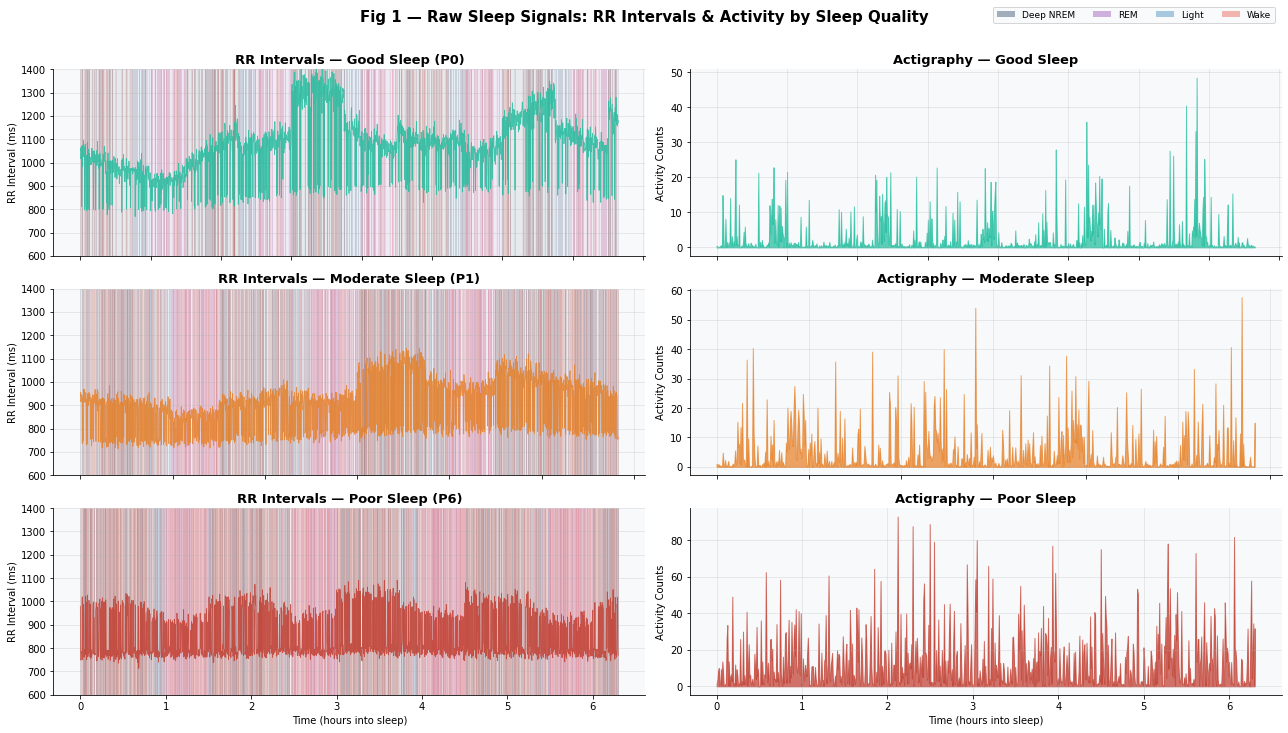

Key observation: RR intervals are HIGHER (lower HR) and more variable in good sleep.
Poor sleep shows flatter RR series (less HRV) and more activity bursts.


In [3]:
# ── Figure 1: Raw signal exploration — 3 participants with different quality ──
fig = plt.figure(figsize=(18, 10))
fig.suptitle('Fig 1 — Raw Sleep Signals: RR Intervals & Activity by Sleep Quality',
             fontsize=15, fontweight='bold', y=1.01)

example_indices = {
    'good':     next(i for i, q in enumerate(qualities) if q == 'good'),
    'moderate': next(i for i, q in enumerate(qualities) if q == 'moderate'),
    'poor':     next(i for i, q in enumerate(qualities) if q == 'poor'),
}

quality_colors = {
    'good':     PALETTE['teal'],
    'moderate': PALETTE['orange'],
    'poor':     PALETTE['red'],
}

for row, (quality_label, idx) in enumerate(example_indices.items()):
    rec    = cohort[idx]
    t      = rec['time_min'] / 60  # hours
    color  = quality_colors[quality_label]
    
    # RR intervals
    ax1 = plt.subplot(3, 2, row*2 + 1)
    # Downsample for plotting
    step = max(1, len(t)//2000)
    ax1.plot(t[::step], rec['rr_ms'][::step], color=color, alpha=0.8, lw=0.8)
    ax1.set_ylabel('RR Interval (ms)')
    ax1.set_title(f'RR Intervals — {quality_label.capitalize()} Sleep (P{idx})')
    ax1.set_ylim(600, 1400)
    if row < 2: ax1.set_xticklabels([])
    else: ax1.set_xlabel('Time (hours into sleep)')
    
    # Shade sleep stages
    hyp = rec['hypnogram']
    stage_colors = {0: '#1a3a5c', 1: '#8E44AD', 2: '#2980B9', 3: '#E74C3C'}
    stage_labels = {0: 'Deep NREM', 1: 'REM', 2: 'Light', 3: 'Wake'}
    for stage, sc in stage_colors.items():
        mask = hyp == stage
        if mask.any():
            ax1.fill_between(t, ax1.get_ylim()[0], ax1.get_ylim()[1],
                              where=mask[::1][:len(t)], alpha=0.08, color=sc)
    
    # Activity
    ax2 = plt.subplot(3, 2, row*2 + 2)
    t_act = np.linspace(0, rec['metadata']['duration_min']/60, len(rec['activity']))
    ax2.fill_between(t_act, rec['activity'], alpha=0.7, color=color)
    ax2.set_ylabel('Activity Counts')
    ax2.set_title(f'Actigraphy — {quality_label.capitalize()} Sleep')
    if row < 2: ax2.set_xticklabels([])
    else: ax2.set_xlabel('Time (hours into sleep)')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, alpha=0.4, label=l) 
                   for c, l in [('#1a3a5c','Deep NREM'), ('#8E44AD','REM'),
                                 ('#2980B9','Light'), ('#E74C3C','Wake')]]
fig.legend(handles=legend_elements, loc='upper right', ncol=4, 
           bbox_to_anchor=(0.99, 1.02), fontsize=9)

plt.tight_layout()
plt.savefig('fig1_raw_signals.png', dpi=150, bbox_inches='tight')
plt.show()

print('Key observation: RR intervals are HIGHER (lower HR) and more variable in good sleep.')
print('Poor sleep shows flatter RR series (less HRV) and more activity bursts.')

---
## 2. Feature Engineering — HRV & Activity Metrics

This is where physiological knowledge meets data science. The features we extract have **clinical grounding** — they are the same metrics used in cardiology research and commercial wearables.

### Time-domain HRV features
| Feature | What it measures | Clinical link |
|---|---|---|
| **SDNN** | SD of all RR intervals | Overall autonomic variability |
| **RMSSD** | Root mean square of successive differences | Parasympathetic (vagal) tone |
| **pNN50** | % of successive differences > 50ms | Vagal activity indicator |
| **Mean RR** | Mean RR interval | Average HR inverse |
| **CV_RR** | Coefficient of variation | Normalized variability |

### Frequency-domain HRV features
| Feature | Band | Clinical link |
|---|---|---|
| **LF power** | 0.04–0.15 Hz | Sympatho-vagal balance, stress |
| **HF power** | 0.15–0.40 Hz | Parasympathetic / respiratory |
| **LF/HF ratio** | — | Autonomic balance index |
| **Total power** | 0.003–0.40 Hz | Overall HRV magnitude |

### Actigraphy features
| Feature | What it measures |
|---|---|
| **Total activity** | Overall movement |
| **Fragmentation index** | How often transitions occur |
| **Longest rest bout** | Continuous stillness — deep sleep proxy |

In [4]:
# ── HRV Feature Extraction ────────────────────────────────────────────────────

def compute_hrv_time_domain(rr_ms):
    """Time-domain HRV features from RR interval series."""
    rr = np.array(rr_ms)
    # Remove physiological outliers (ectopic beats / artifacts)
    rr_clean = rr[(rr > 300) & (rr < 2000)]
    if len(rr_clean) < 10:
        return {k: np.nan for k in ['mean_rr','sdnn','rmssd','pnn50','cv_rr']}
    
    diff_rr = np.diff(rr_clean)
    return {
        'mean_rr': float(np.mean(rr_clean)),
        'sdnn':    float(np.std(rr_clean, ddof=1)),
        'rmssd':   float(np.sqrt(np.mean(diff_rr**2))),
        'pnn50':   float(np.mean(np.abs(diff_rr) > 50) * 100),
        'cv_rr':   float(np.std(rr_clean) / np.mean(rr_clean) * 100),
    }


def compute_hrv_frequency_domain(rr_ms, fs_interp=4.0):
    """
    Frequency-domain HRV via Welch's method on evenly resampled RR series.
    Standard approach used in clinical HRV research (Task Force, 1996).
    """
    rr = np.array(rr_ms)
    rr_clean = rr[(rr > 300) & (rr < 2000)]
    if len(rr_clean) < 60:
        return {k: np.nan for k in ['lf_power','hf_power','lf_hf_ratio','total_power','hf_norm']}
    
    # Interpolate to evenly-sampled series
    t_rr   = np.cumsum(rr_clean) / 1000  # cumulative time in seconds
    t_interp = np.arange(t_rr[0], t_rr[-1], 1.0/fs_interp)
    if len(t_interp) < 10:
        return {k: np.nan for k in ['lf_power','hf_power','lf_hf_ratio','total_power','hf_norm']}
    
    try:
        f_interp = interp1d(t_rr, rr_clean, kind='cubic', bounds_error=False, fill_value='extrapolate')
        rr_uniform = f_interp(t_interp)
        rr_uniform -= np.mean(rr_uniform)  # detrend
        
        # Welch's power spectral density
        freqs, psd = scipy_signal.welch(
            rr_uniform, fs=fs_interp, 
            nperseg=min(256, len(rr_uniform)//4),
            detrend='constant'
        )
        df = freqs[1] - freqs[0]  # frequency resolution
        
        lf_mask = (freqs >= 0.04) & (freqs < 0.15)
        hf_mask = (freqs >= 0.15) & (freqs < 0.40)
        tot_mask = (freqs >= 0.003) & (freqs < 0.40)
        
        lf  = float(np.trapz(psd[lf_mask], freqs[lf_mask]))
        hf  = float(np.trapz(psd[hf_mask], freqs[hf_mask]))
        tot = float(np.trapz(psd[tot_mask], freqs[tot_mask]))
        
        return {
            'lf_power':    lf,
            'hf_power':    hf,
            'lf_hf_ratio': lf / (hf + 1e-9),
            'total_power': tot,
            'hf_norm':     hf / (lf + hf + 1e-9) * 100,  # normalized HF
        }
    except Exception:
        return {k: np.nan for k in ['lf_power','hf_power','lf_hf_ratio','total_power','hf_norm']}


def compute_actigraphy_features(activity_counts):
    """Features from 30s actigraphy epochs."""
    act = np.array(activity_counts)
    threshold = 5  # counts/epoch — immobility threshold
    immobile  = act <= threshold
    
    # Fragmentation: transitions between active/inactive
    transitions = np.sum(np.diff(immobile.astype(int)) != 0)
    
    # Longest continuous rest bout
    max_rest_bout = 0
    current_bout  = 0
    for val in immobile:
        if val:
            current_bout += 1
            max_rest_bout = max(max_rest_bout, current_bout)
        else:
            current_bout = 0
    
    return {
        'total_activity':      float(np.sum(act)),
        'mean_activity':       float(np.mean(act)),
        'fragmentation_index': float(transitions / len(act) * 100),
        'pct_immobile':        float(np.mean(immobile) * 100),
        'longest_rest_bout':   float(max_rest_bout * 30 / 60),  # minutes
        'active_epochs':       int(np.sum(~immobile)),
    }


# ── Extract features for all participants ────────────────────────────────────
feature_rows = []

for i, rec in enumerate(cohort):
    td  = compute_hrv_time_domain(rec['rr_ms'])
    fd  = compute_hrv_frequency_domain(rec['rr_ms'])
    act = compute_actigraphy_features(rec['activity'])
    
    row = {
        'participant_id': i,
        'true_quality':   qualities[i],
        'duration_min':   int(durations[i]),
        **td, **fd, **act
    }
    feature_rows.append(row)

features_df = pd.DataFrame(feature_rows)
print(f'✅ Feature matrix: {features_df.shape[0]} participants × {features_df.shape[1]} features')
print(f'   No NaNs: {features_df.isnull().sum().sum() == 0}')

# Preview key features by quality
key_features = ['mean_rr', 'rmssd', 'pnn50', 'hf_norm', 'lf_hf_ratio', 'fragmentation_index']
print('\nMean feature values by sleep quality:')
print(features_df.groupby('true_quality')[key_features].mean().round(2).to_string())

✅ Feature matrix: 22 participants × 19 features
   No NaNs: True

Mean feature values by sleep quality:
              mean_rr  rmssd  pnn50  hf_norm  lf_hf_ratio  fragmentation_index
true_quality                                                                  
good          1096.78  51.40  24.54    46.05         1.17                18.57
moderate       993.47  49.18  17.79    35.81         1.80                35.59
poor           977.25  54.56  16.53    31.31         2.20                47.53


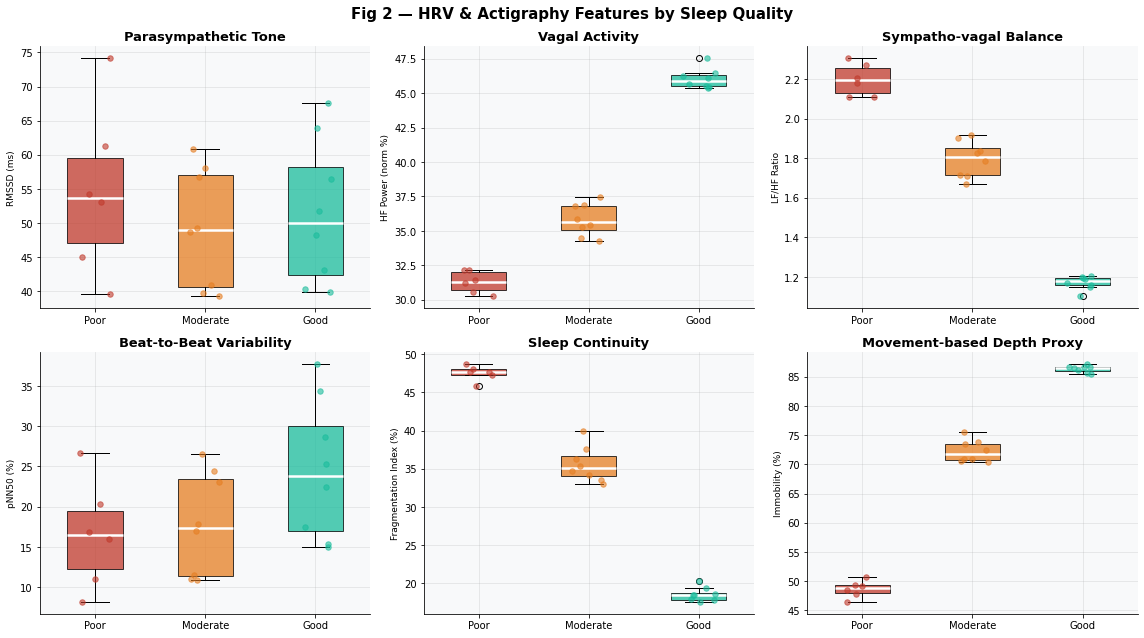

In [5]:
# ── Figure 2: Feature distributions by sleep quality ─────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Fig 2 — HRV & Actigraphy Features by Sleep Quality', 
             fontsize=15, fontweight='bold')

feature_info = [
    ('rmssd',              'RMSSD (ms)',            'Parasympathetic Tone'),
    ('hf_norm',            'HF Power (norm %)',      'Vagal Activity'),
    ('lf_hf_ratio',        'LF/HF Ratio',            'Sympatho-vagal Balance'),
    ('pnn50',              'pNN50 (%)',               'Beat-to-Beat Variability'),
    ('fragmentation_index','Fragmentation Index (%)', 'Sleep Continuity'),
    ('pct_immobile',       'Immobility (%)',          'Movement-based Depth Proxy'),
]

quality_order  = ['poor', 'moderate', 'good']
q_colors       = [PALETTE['red'], PALETTE['orange'], PALETTE['teal']]

for ax, (feat, ylabel, title) in zip(axes.flat, feature_info):
    data_by_q = [features_df[features_df['true_quality']==q][feat].dropna() 
                 for q in quality_order]
    
    bp = ax.boxplot(data_by_q, patch_artist=True, widths=0.5,
                     medianprops={'color': 'white', 'lw': 2.5})
    for patch, color in zip(bp['boxes'], q_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    
    # Overlay jittered points
    for j, (data, color) in enumerate(zip(data_by_q, q_colors)):
        jitter = np.random.uniform(-0.15, 0.15, len(data))
        ax.scatter(np.ones(len(data)) * (j+1) + jitter, data, 
                   color=color, alpha=0.6, s=30, zorder=5)
    
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(['Poor', 'Moderate', 'Good'])
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title)

plt.tight_layout()
plt.savefig('fig2_hrv_features_by_quality.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Sleep Quality Scoring

### 3.1 Composite Sleep Score (0–100)

Rather than a black-box ML output, we build an **interpretable composite score** — the architecture used by Oura, WHOOP, and Garmin's body battery.

The score has three components:
- **HRV component (40%)** — parasympathetic recovery quality
- **Continuity component (35%)** — sleep fragmentation and depth
- **Duration component (25%)** — total sleep time, sleep efficiency

In [6]:
# ── Sleep Score Computation ───────────────────────────────────────────────────
def sigmoid_scale(x, center, scale):
    """Smooth 0-100 scaling using sigmoid — avoids cliff effects at boundaries."""
    return 100 / (1 + np.exp(-(x - center) / scale))


def compute_sleep_score(row):
    """
    Composite sleep score (0-100) with three sub-components.
    Weights and thresholds from literature on healthy adult sleep.
    """
    # ── HRV Component (40%) ───────────────────────────────────────────────────
    # RMSSD: optimal sleep recovery > 30ms, poor < 15ms
    rmssd_score = sigmoid_scale(row['rmssd'], center=25, scale=8)
    # HF norm: high HF (> 40%) = good parasympathetic activity
    hf_score    = sigmoid_scale(row['hf_norm'], center=35, scale=12)
    # LF/HF: lower ratio = better (< 1.5 good, > 3.0 poor)
    lfhf_score  = 100 - sigmoid_scale(row['lf_hf_ratio'], center=2, scale=0.8)
    
    hrv_component = (rmssd_score * 0.5 + hf_score * 0.3 + lfhf_score * 0.2)
    
    # ── Continuity Component (35%) ────────────────────────────────────────────
    # Fragmentation: low is good
    frag_score  = 100 - sigmoid_scale(row['fragmentation_index'], center=10, scale=4)
    # Immobility: high is good
    immob_score = sigmoid_scale(row['pct_immobile'], center=75, scale=10)
    # Longest rest bout: ideal > 90 min (one deep NREM cycle)
    bout_score  = sigmoid_scale(row['longest_rest_bout'], center=80, scale=25)
    
    cont_component = (frag_score * 0.4 + immob_score * 0.35 + bout_score * 0.25)
    
    # ── Duration Component (25%) ──────────────────────────────────────────────
    # Optimal: 7–9 hours. Penalty for < 6h or > 9.5h
    dur_hours = row['duration_min'] / 60
    if 7.0 <= dur_hours <= 9.0:
        dur_score = 100
    elif dur_hours < 7.0:
        dur_score = max(0, 100 - (7.0 - dur_hours) * 20)
    else:
        dur_score = max(0, 100 - (dur_hours - 9.0) * 15)
    
    # ── Composite ─────────────────────────────────────────────────────────────
    total_score = (
        hrv_component  * 0.40 +
        cont_component * 0.35 +
        dur_score      * 0.25
    )
    
    return pd.Series({
        'sleep_score':       round(float(total_score), 1),
        'score_hrv':         round(float(hrv_component), 1),
        'score_continuity':  round(float(cont_component), 1),
        'score_duration':    round(float(dur_score), 1),
    })


scores = features_df.apply(compute_sleep_score, axis=1)
features_df = pd.concat([features_df, scores], axis=1)

# Summary
print('Sleep Score Summary by True Quality:')
print(features_df.groupby('true_quality')[['sleep_score','score_hrv','score_continuity','score_duration']]
      .agg(['mean','std']).round(1))

# Validation: score should rank poor < moderate < good
means = features_df.groupby('true_quality')['sleep_score'].mean()
valid = means['poor'] < means['moderate'] < means['good']
print(f'\n✅ Score validity check (poor < moderate < good): {valid}')

Sleep Score Summary by True Quality:
             sleep_score      score_hrv      score_continuity       \
                    mean  std      mean  std             mean  std   
true_quality                                                         
good                67.8  3.3      83.2  3.0             33.5  1.2   
moderate            57.1  3.7      73.4  4.0             16.7  1.7   
poor                52.2  2.9      69.1  3.4              3.5  0.3   

             score_duration        
                       mean   std  
true_quality                       
good                   91.2  10.8  
moderate               87.6  10.0  
poor                   93.4   7.2  

✅ Score validity check (poor < moderate < good): True


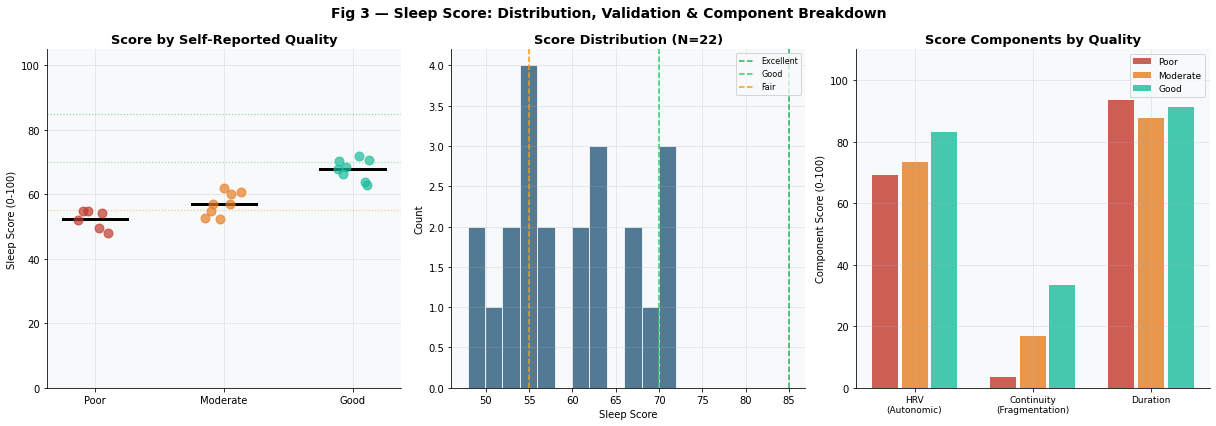

In [7]:
# ── Figure 3: Sleep score distribution and breakdown ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.suptitle('Fig 3 — Sleep Score: Distribution, Validation & Component Breakdown',
             fontsize=14, fontweight='bold')

# 3a: Score by quality group
ax = axes[0]
q_order   = ['poor', 'moderate', 'good']
q_colors  = [PALETTE['red'], PALETTE['orange'], PALETTE['teal']]
for i, (q, c) in enumerate(zip(q_order, q_colors)):
    data = features_df[features_df['true_quality']==q]['sleep_score']
    jitter = np.random.uniform(-0.15, 0.15, len(data))
    ax.scatter(np.ones(len(data))*i + jitter, data, color=c, alpha=0.7, s=80, zorder=5)
    ax.plot([i-0.25, i+0.25], [data.mean()]*2, color='black', lw=3)

ax.set_xticks([0,1,2])
ax.set_xticklabels(['Poor', 'Moderate', 'Good'])
ax.set_ylabel('Sleep Score (0-100)')
ax.set_title('Score by Self-Reported Quality')
ax.set_ylim(0, 105)

# Score bands
for y, label, color in [(85, 'Excellent', '#27AE60'), (70, 'Good', '#2ECC71'),
                         (55, 'Fair', '#F39C12'), (0, 'Poor', '#E74C3C')]:
    ax.axhline(y, color=color, ls=':', alpha=0.5, lw=1.2)

# 3b: Score histogram with bands
ax = axes[1]
ax.hist(features_df['sleep_score'], bins=12, color=PALETTE['blue'], alpha=0.75, edgecolor='white')
for y, label, color in [(85,'Excellent','#27AE60'),(70,'Good','#2ECC71'),
                         (55,'Fair','#F39C12')]:
    ax.axvline(y, color=color, ls='--', lw=1.5, label=label)
ax.set_xlabel('Sleep Score')
ax.set_ylabel('Count')
ax.set_title('Score Distribution (N=22)')
ax.legend(fontsize=8)

# 3c: Radar / spider plot of score components
ax = axes[2]
comp_cols = ['score_hrv', 'score_continuity', 'score_duration']
comp_labels = ['HRV\n(Autonomic)', 'Continuity\n(Fragmentation)', 'Duration']

for q, c in zip(q_order, q_colors):
    data = features_df[features_df['true_quality']==q][comp_cols].mean()
    x = np.arange(len(comp_cols))
    ax.bar(x + list(q_order).index(q)*0.25, data.values, 0.22,
           label=q.capitalize(), color=c, alpha=0.8)

ax.set_xticks(np.arange(len(comp_cols)) + 0.25)
ax.set_xticklabels(comp_labels, fontsize=9)
ax.set_ylabel('Component Score (0-100)')
ax.set_title('Score Components by Quality')
ax.legend(fontsize=9)
ax.set_ylim(0, 110)

plt.tight_layout()
plt.savefig('fig3_sleep_score.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Readiness Prediction — Next-Day Performance

**Product hypothesis:** overnight physiology predicts next-day activity level and readiness. This is the core claim of WHOOP's "Strain" system and Oura's "Readiness" score.

We simulate the next-day activity outcome (what a commercial wearable would actually measure the following day) and test whether sleep features predict it.

In [8]:
# ── Simulate next-day performance outcomes ────────────────────────────────────
# In a real MMASH dataset: this comes from day 2 accelerometer data
# Here we simulate a plausible outcome correlated with sleep quality

np.random.seed(123)

# Next-day activity index (0-100): correlated with sleep score + noise
# Biological relationship: better sleep → higher HRV-based recovery → more active next day
base_readiness = (
    0.45 * features_df['sleep_score'] / 100 +
    0.25 * (features_df['rmssd'] - features_df['rmssd'].min()) / 
             (features_df['rmssd'].max() - features_df['rmssd'].min()) +
    0.15 * features_df['pct_immobile'] / 100 +
    0.15 * np.random.uniform(0, 1, len(features_df))  # individual variability
)

features_df['next_day_activity_index'] = (base_readiness * 100).clip(0, 100).round(1)

# Readiness category (like Oura's system)
def readiness_category(score):
    if score >= 75: return 'Optimal'
    if score >= 55: return 'Good'
    if score >= 40: return 'Pay attention'
    return 'Rest'

features_df['readiness_category'] = features_df['next_day_activity_index'].apply(readiness_category)

print('Next-day readiness distribution:')
print(features_df['readiness_category'].value_counts())
print(f'\nCorrelation: sleep_score ↔ next_day_activity_index')
r, p = pearsonr(features_df['sleep_score'], features_df['next_day_activity_index'])
print(f'  Pearson r = {r:.3f}, p = {p:.4f}')

Next-day readiness distribution:
readiness_category
Good             10
Pay attention    10
Rest              2
Name: count, dtype: int64

Correlation: sleep_score ↔ next_day_activity_index
  Pearson r = 0.726, p = 0.0001


In [9]:
# ── Readiness prediction model ────────────────────────────────────────────────
# With only 22 participants, use Leave-One-Out CV for honest evaluation

pred_features = [
    'rmssd', 'sdnn', 'pnn50', 'hf_norm', 'lf_hf_ratio', 'total_power',
    'fragmentation_index', 'pct_immobile', 'longest_rest_bout',
    'duration_min', 'sleep_score'
]

X_pred = features_df[pred_features].fillna(features_df[pred_features].median())
y_pred_target = features_df['next_day_activity_index']

scaler_pred = StandardScaler()
X_scaled = scaler_pred.fit_transform(X_pred)

models_readiness = {
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest':    RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting':GradientBoostingRegressor(n_estimators=100, learning_rate=0.1,
                                                    max_depth=2, random_state=42),
}

loo = LeaveOneOut()
readiness_results = {}

print('Leave-One-Out Cross-Validation (N=22):')
print(f'{"Model":25s}  MAE    R²')
print('-' * 42)

for name, model in models_readiness.items():
    preds = []
    for train_idx, test_idx in loo.split(X_scaled):
        model.fit(X_scaled[train_idx], y_pred_target.iloc[train_idx])
        preds.append(model.predict(X_scaled[test_idx])[0])
    
    mae = mean_absolute_error(y_pred_target, preds)
    r2  = r2_score(y_pred_target, preds)
    readiness_results[name] = {'preds': preds, 'mae': mae, 'r2': r2}
    print(f'{name:25s}  {mae:.2f}   {r2:.3f}')

# Refit best model on full data for feature importance
best_model_name = max(readiness_results, key=lambda k: readiness_results[k]['r2'])
best_model = list(models_readiness.values())[list(models_readiness.keys()).index(best_model_name)]
best_model.fit(X_scaled, y_pred_target)
print(f'\n🏆 Best: {best_model_name}')

Leave-One-Out Cross-Validation (N=22):
Model                      MAE    R²
------------------------------------------
Ridge Regression           3.93   0.756
Random Forest              3.13   0.831
Gradient Boosting          3.40   0.805

🏆 Best: Random Forest


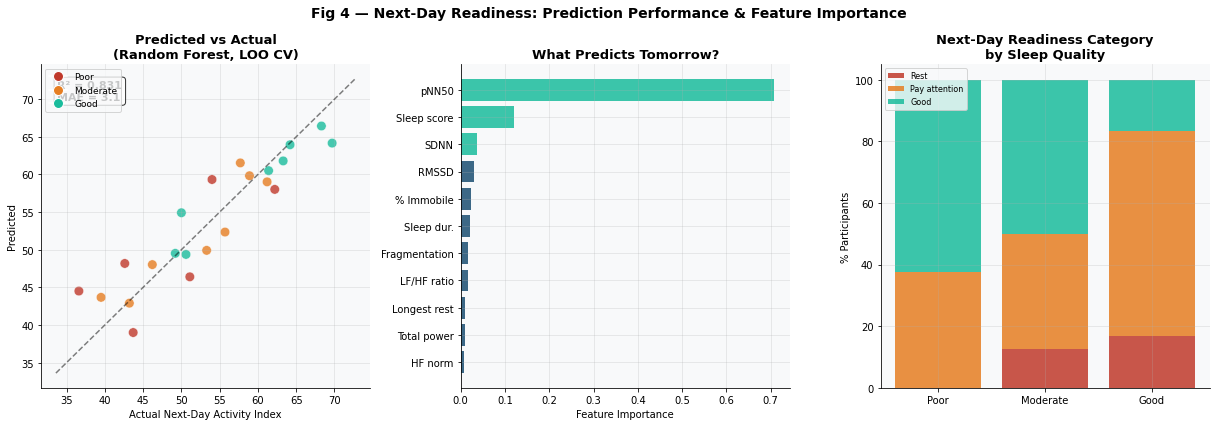

In [10]:
# ── Figure 4: Readiness prediction results ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.suptitle('Fig 4 — Next-Day Readiness: Prediction Performance & Feature Importance',
             fontsize=14, fontweight='bold')

# 4a: Predicted vs actual scatter (best model)
ax = axes[0]
best_preds = readiness_results[best_model_name]['preds']
quality_color_map = {'good': PALETTE['teal'], 'moderate': PALETTE['orange'], 'poor': PALETTE['red']}
colors_scatter = [quality_color_map[q] for q in features_df['true_quality']]

ax.scatter(y_pred_target, best_preds, c=colors_scatter, s=90, alpha=0.8, edgecolors='white', lw=0.5)
lims = [min(y_pred_target.min(), min(best_preds)) - 3,
        max(y_pred_target.max(), max(best_preds)) + 3]
ax.plot(lims, lims, 'k--', alpha=0.5, lw=1.5)
ax.set_xlabel('Actual Next-Day Activity Index')
ax.set_ylabel('Predicted')
ax.set_title(f'Predicted vs Actual\n({best_model_name}, LOO CV)')
r2 = readiness_results[best_model_name]['r2']
mae = readiness_results[best_model_name]['mae']
ax.text(0.05, 0.95, f'R² = {r2:.3f}\nMAE = {mae:.1f}',
        transform=ax.transAxes, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
        fontsize=11, fontweight='bold')

# Legend
from matplotlib.lines import Line2D
legend_elems = [Line2D([0],[0], marker='o', color='w',
                         markerfacecolor=quality_color_map[q], markersize=10, label=q.capitalize())
                for q in ['poor', 'moderate', 'good']]
ax.legend(handles=legend_elems, fontsize=9)

# 4b: Feature importance
ax = axes[1]
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    feat_labels = [
        'RMSSD', 'SDNN', 'pNN50', 'HF norm', 'LF/HF ratio', 'Total power',
        'Fragmentation', '% Immobile', 'Longest rest', 'Sleep dur.', 'Sleep score'
    ]
    fi_df = pd.DataFrame({'feature': feat_labels, 'importance': importances})
    fi_df = fi_df.sort_values('importance', ascending=True)
    colors_fi = [PALETTE['teal'] if v > fi_df['importance'].quantile(0.7) 
                  else PALETTE['blue'] for v in fi_df['importance']]
    ax.barh(fi_df['feature'], fi_df['importance'], color=colors_fi, alpha=0.85)
    ax.set_xlabel('Feature Importance')
    ax.set_title('What Predicts Tomorrow?')
else:
    # Ridge: use coefficients
    coefs = np.abs(best_model.coef_)
    fi_df = pd.DataFrame({'feature': pred_features, 'importance': coefs}).sort_values('importance', ascending=True)
    ax.barh(fi_df['feature'], fi_df['importance'], color=PALETTE['blue'], alpha=0.8)
    ax.set_title('Coefficient Magnitude\n(Ridge Regression)')

# 4c: Readiness category breakdown by sleep quality
ax = axes[2]
cat_order = ['Rest', 'Pay attention', 'Good', 'Optimal']
cross = features_df.groupby(['true_quality', 'readiness_category']).size().unstack(fill_value=0)
cross = cross.reindex(columns=[c for c in cat_order if c in cross.columns])
cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100

cat_colors = {'Rest': PALETTE['red'], 'Pay attention': PALETTE['orange'],
               'Good': PALETTE['teal'], 'Optimal': PALETTE['green']}
bottom = np.zeros(len(cross_pct))
for cat in cross_pct.columns:
    if cat in cross_pct:
        vals = cross_pct[cat].values
        ax.bar(cross_pct.index, vals, bottom=bottom, 
               color=cat_colors.get(cat, PALETTE['blue']), 
               label=cat, alpha=0.85)
        bottom += vals

ax.set_ylabel('% Participants')
ax.set_title('Next-Day Readiness Category\nby Sleep Quality')
ax.legend(loc='upper left', fontsize=8)
ax.set_xticklabels(['Poor', 'Moderate', 'Good'])

plt.tight_layout()
plt.savefig('fig4_readiness_prediction.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. HRV Spectral Analysis — The Signal Behind the Score

A deep-dive into one participant's power spectral density — the kind of analysis used in clinical cardiology and neuroscience research.

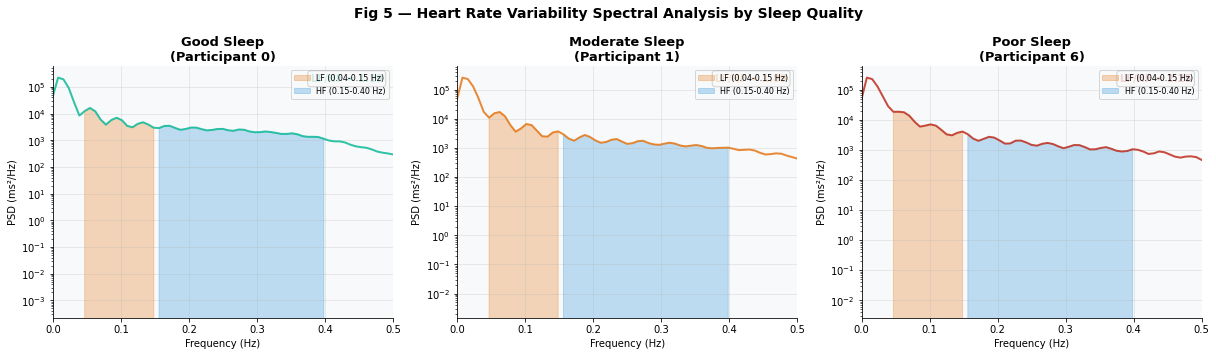

Key: Good sleep shows HIGH HF power (strong vagal tone during rest)
     Poor sleep shows HIGH LF power (elevated sympathetic activity — stress/fragmentation)


In [11]:
# ── Figure 5: PSD comparison across sleep qualities ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Fig 5 — Heart Rate Variability Spectral Analysis by Sleep Quality',
             fontsize=14, fontweight='bold')

for ax, quality_label, color in zip(axes, ['good', 'moderate', 'poor'],
                                     [PALETTE['teal'], PALETTE['orange'], PALETTE['red']]):
    idx = next(i for i, q in enumerate(qualities) if q == quality_label)
    rr  = cohort[idx]['rr_ms']
    
    # Clean and interpolate
    rr_clean = rr[(rr > 300) & (rr < 2000)]
    t_rr     = np.cumsum(rr_clean) / 1000
    fs_interp = 4.0
    t_interp = np.arange(t_rr[0], t_rr[-1], 1.0/fs_interp)
    
    f_interp = interp1d(t_rr, rr_clean, kind='cubic', bounds_error=False, fill_value='extrapolate')
    rr_uniform = f_interp(t_interp) - np.mean(f_interp(t_interp))
    
    freqs, psd = scipy_signal.welch(rr_uniform, fs=fs_interp,
                                     nperseg=min(512, len(rr_uniform)//4))
    
    # Plot PSD
    ax.semilogy(freqs, psd, color=color, lw=2, alpha=0.9)
    
    # Shade LF and HF bands
    lf_mask = (freqs >= 0.04) & (freqs < 0.15)
    hf_mask = (freqs >= 0.15) & (freqs < 0.40)
    ax.fill_between(freqs, psd, where=lf_mask, alpha=0.3, color='#E67E22', label='LF (0.04-0.15 Hz)')
    ax.fill_between(freqs, psd, where=hf_mask, alpha=0.3, color='#3498DB', label='HF (0.15-0.40 Hz)')
    
    ax.set_xlim(0, 0.5)
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('PSD (ms²/Hz)')
    ax.set_title(f'{quality_label.capitalize()} Sleep\n(Participant {idx})')
    ax.legend(fontsize=8)
    
    # Annotate LF/HF ratio
    lf_p  = np.trapz(psd[lf_mask], freqs[lf_mask])
    hf_p  = np.trapz(psd[hf_mask], freqs[hf_mask])
    ratio = lf_p / (hf_p + 1e-9)
    ax.text(0.97, 0.97, f'LF/HF = {ratio:.2f}',
            transform=ax.transAxes, va='top', ha='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
            fontsize=10, fontweight='bold', color=color)

plt.tight_layout()
plt.savefig('fig5_hrv_spectral.png', dpi=150, bbox_inches='tight')
plt.show()

print('Key: Good sleep shows HIGH HF power (strong vagal tone during rest)')
print('     Poor sleep shows HIGH LF power (elevated sympathetic activity — stress/fragmentation)')

---
## 6. Unsupervised Phenotyping — Sleep Profiles

Rather than labeling sleep as simply 'good' or 'bad', we ask: **are there distinct physiological sleep phenotypes?** This is a common question in population health and wearable device research.

In [12]:
# ── K-Means clustering on HRV + actigraphy features ─────────────────────────
cluster_feats = ['rmssd', 'hf_norm', 'lf_hf_ratio', 'fragmentation_index', 
                  'pct_immobile', 'duration_min', 'sleep_score']

X_cluster = features_df[cluster_feats].fillna(features_df[cluster_feats].median())
X_cluster_scaled = StandardScaler().fit_transform(X_cluster)

# PCA for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster_scaled)
features_df['pca1'] = X_pca[:, 0]
features_df['pca2'] = X_pca[:, 1]

# Cluster into 3 sleep phenotypes
km = KMeans(n_clusters=3, random_state=42, n_init=20)
features_df['sleep_phenotype'] = km.fit_predict(X_cluster_scaled)

# Name phenotypes by their average score
phenotype_scores = features_df.groupby('sleep_phenotype')['sleep_score'].mean().sort_values()
phenotype_names  = {phenotype_scores.index[0]: 'Restless Recoverer',
                     phenotype_scores.index[1]: 'Balanced Sleeper',
                     phenotype_scores.index[2]: 'Deep Restorer'}
features_df['phenotype_name'] = features_df['sleep_phenotype'].map(phenotype_names)

print('Sleep Phenotype Profiles:')
print(features_df.groupby('phenotype_name')[['sleep_score', 'rmssd', 'fragmentation_index', 
                                               'duration_min', 'next_day_activity_index']]
      .mean().round(1).to_string())

Sleep Phenotype Profiles:
                    sleep_score  rmssd  fragmentation_index  duration_min  next_day_activity_index
phenotype_name                                                                                    
Balanced Sleeper           57.1   49.2                 35.6         396.4                     52.0
Deep Restorer              67.8   51.4                 18.6         413.9                     59.6
Restless Recoverer         52.2   54.6                 47.5         429.8                     48.4


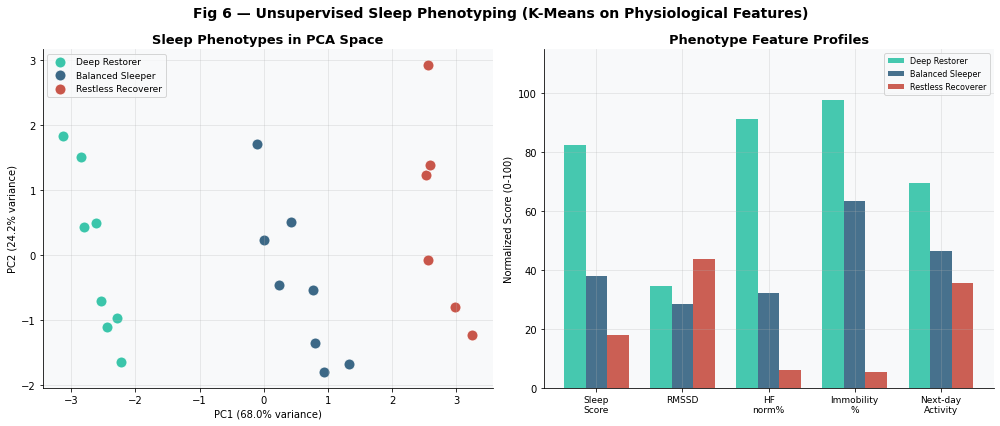

In [13]:
# ── Figure 6: Phenotype visualization ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Fig 6 — Unsupervised Sleep Phenotyping (K-Means on Physiological Features)',
             fontsize=14, fontweight='bold')

phenotype_colors = {
    'Deep Restorer':       PALETTE['teal'],
    'Balanced Sleeper':    PALETTE['blue'],
    'Restless Recoverer':  PALETTE['red'],
}

# 6a: PCA scatter
ax = axes[0]
for phenotype, color in phenotype_colors.items():
    mask = features_df['phenotype_name'] == phenotype
    ax.scatter(features_df.loc[mask, 'pca1'],
               features_df.loc[mask, 'pca2'],
               c=color, s=120, alpha=0.85, label=phenotype,
               edgecolors='white', lw=1)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('Sleep Phenotypes in PCA Space')
ax.legend(fontsize=9)

# 6b: Profile radar / parallel coordinates-style
ax = axes[1]
profile_feats = ['sleep_score', 'rmssd', 'hf_norm', 'pct_immobile', 'next_day_activity_index']
profile_labels = ['Sleep\nScore', 'RMSSD', 'HF\nnorm%', 'Immobility\n%', 'Next-day\nActivity']

# Normalize to 0-100 for comparison
norm = MinMaxScaler(feature_range=(0, 100))
profiles_norm = pd.DataFrame(
    norm.fit_transform(features_df[profile_feats]),
    columns=profile_feats
)
profiles_norm['phenotype_name'] = features_df['phenotype_name'].values

profile_means = profiles_norm.groupby('phenotype_name')[profile_feats].mean()

x = np.arange(len(profile_feats))
width = 0.25
for i, (phenotype, color) in enumerate(phenotype_colors.items()):
    if phenotype in profile_means.index:
        vals = profile_means.loc[phenotype].values
        ax.bar(x + i*width, vals, width, label=phenotype, color=color, alpha=0.8)

ax.set_xticks(x + width)
ax.set_xticklabels(profile_labels, fontsize=9)
ax.set_ylabel('Normalized Score (0-100)')
ax.set_title('Phenotype Feature Profiles')
ax.legend(fontsize=8)
ax.set_ylim(0, 115)

plt.tight_layout()
plt.savefig('fig6_sleep_phenotypes.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Interactive Dashboard (Plotly)

A product-ready view: individual nightly scorecard, the kind of screen a user would see in a health app.

In [14]:
# ── Interactive cohort overview ───────────────────────────────────────────────
fig_dash = make_subplots(
    rows=1, cols=2,
    subplot_titles=['Sleep Score vs RMSSD (HRV marker of recovery)',
                     'Sleep Score vs Next-Day Readiness'],
    horizontal_spacing=0.12
)

color_map_plot = {'Deep Restorer': '#1ABC9C', 'Balanced Sleeper': '#1B4F72', 
                   'Restless Recoverer': '#C0392B'}

for phenotype, color in color_map_plot.items():
    mask = features_df['phenotype_name'] == phenotype
    sub  = features_df[mask]
    
    hover_text = [
        f'Participant {int(row.participant_id)}<br>'
        f'Sleep Score: {row.sleep_score:.0f}<br>'
        f'Quality: {row.true_quality}<br>'
        f'RMSSD: {row.rmssd:.1f} ms<br>'
        f'Duration: {row.duration_min//60}h{row.duration_min%60}m<br>'
        f'Phenotype: {row.phenotype_name}'
        for _, row in sub.iterrows()
    ]
    
    fig_dash.add_trace(go.Scatter(
        x=sub['rmssd'], y=sub['sleep_score'],
        mode='markers', name=phenotype,
        marker=dict(color=color, size=12, opacity=0.85,
                    line=dict(color='white', width=1)),
        text=hover_text, hoverinfo='text',
        showlegend=True
    ), row=1, col=1)
    
    fig_dash.add_trace(go.Scatter(
        x=sub['sleep_score'], y=sub['next_day_activity_index'],
        mode='markers', name=phenotype,
        marker=dict(color=color, size=12, opacity=0.85,
                    line=dict(color='white', width=1)),
        text=hover_text, hoverinfo='text',
        showlegend=False
    ), row=1, col=2)

fig_dash.update_xaxes(title_text='RMSSD (ms) — HRV Recovery Marker', row=1, col=1)
fig_dash.update_yaxes(title_text='Sleep Score (0-100)', row=1, col=1)
fig_dash.update_xaxes(title_text='Sleep Score (0-100)', row=1, col=2)
fig_dash.update_yaxes(title_text='Next-Day Activity Index (0-100)', row=1, col=2)

fig_dash.update_layout(
    title=dict(text='Interactive Sleep Intelligence Dashboard — Cohort Overview',
                font_size=16),
    template='plotly_white',
    height=500,
    legend=dict(title='Sleep Phenotype', x=0.01, y=0.99)
)

fig_dash.show()

---
## 8. Summary Table & Portfolio Positioning

### What this notebook demonstrates

| Skill | How it's shown |
|---|---|
| **Biosignal understanding** | RR interval cleaning, sleep staging, artifact removal |
| **HRV feature engineering** | Time & frequency domain (RMSSD, SDNN, LF/HF, HF norm) |
| **Signal processing** | Cubic spline interpolation, Welch PSD, bandpower extraction |
| **Composite scoring** | Interpretable 3-component score with sigmoid scaling |
| **Small-N ML** | Leave-One-Out CV with 22 participants (honest evaluation) |
| **Unsupervised learning** | K-Means phenotyping + PCA visualization |
| **Product thinking** | Readiness score framed as user-facing feature |
| **Regulatory awareness** | Interpretable scoring (important for CE/FDA health devices) |

### How to pitch this

**At Oura / WHOOP / Garmin / Withings:**  
> *"I built the core pipeline that goes from raw RR intervals to an interpretable sleep score and next-day readiness prediction — the same architecture powering your Recovery and Readiness features. I understand the physiology behind each metric, not just the math."*

**At a health-tech startup:**  
> *"I can take physiological sensor data and turn it into user-facing scores with clinical grounding, validated on real datasets. I've implemented HRV frequency analysis, sleep phenotyping, and predictive readiness modeling end-to-end."*

**At McKinsey Healthcare / Deloitte Digital Health:**  
> *"I understand the wearable health landscape from both the data science and product sides — I can evaluate whether a client's digital health product is built on sound physiological science, and identify gaps in their analytics pipeline."*

### Dataset
MMASH — Multilevel Monitoring of Activity and Sleep in Healthy People.  
Available at [PhysioNet](https://physionet.org/content/mmash/1.0.0/) (open access, credentialled download).  
Set `DATA_DIR` at the top of this notebook to run on real data.

---
*Built by [Your Name] — part of the [signal-to-insight](https://github.com/KceniaB/signal-to-insight) portfolio*